# Data Loading and First Look

Before we train anything, score anything, or stress-test anything, we need to actually look at the data. This notebook loads HH-RLHF, flattens it into a usable shape, and asks the most basic questions: how big is it, what does a row look like, and are chosen responses actually different from rejected ones?

First run downloads the dataset (~1 GB). Every run after that loads from local cache.

In [1]:
import sys
sys.path.insert(0, '../../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from inference_lens.data.loader import load_hh_rlhf, flatten_hh_rlhf, split_dataframe
from inference_lens.utils.logging import setup_logging

setup_logging()
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 120)

## Load HH-RLHF

Pulling both subsets from HuggingFace: helpful-base (responses that are actually useful) and harmless-base (responses that don't cause harm). Together they cover the two things Anthropic cared about when collecting this data.

In [2]:
datasets = load_hh_rlhf(cache_dir='../../data/raw')

for subset, ds in datasets.items():
    print(f'{subset}: {ds}')

2026-05-15 18:54:25  INFO      inference_lens.data.loader  Loading HH-RLHF subsets: ('helpful-base', 'harmless-base')
2026-05-15 18:54:25  INFO      httpx  HTTP Request: HEAD https://huggingface.co/datasets/anthropic/hh-rlhf/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-05-15 18:54:25  INFO      httpx  HTTP Request: HEAD https://huggingface.co/datasets/Anthropic/hh-rlhf/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-05-15 18:54:25  INFO      httpx  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/Anthropic/hh-rlhf/09be8c5bbc57cb3887f3a9732ad6aa7ec602a1fa/README.md "HTTP/1.1 200 OK"
2026-05-15 18:54:25  INFO      httpx  HTTP Request: HEAD https://huggingface.co/datasets/anthropic/hh-rlhf/resolve/09be8c5bbc57cb3887f3a9732ad6aa7ec602a1fa/hh-rlhf.py "HTTP/1.1 307 Temporary Redirect"
2026-05-15 18:54:25  INFO      httpx  HTTP Request: HEAD https://huggingface.co/datasets/Anthropic/hh-rlhf/resolve/09be8c5bbc57cb3887f3a9732ad6aa7ec602a1fa/hh-

2026-05-15 18:54:25  WARNING   huggingface_hub.utils._http  Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-15 18:54:26  INFO      httpx  HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/anthropic/hh-rlhf/anthropic/hh-rlhf.py "HTTP/1.1 404 Not Found"
2026-05-15 18:54:26  INFO      httpx  HTTP Request: GET https://huggingface.co/api/datasets/anthropic/hh-rlhf/revision/09be8c5bbc57cb3887f3a9732ad6aa7ec602a1fa "HTTP/1.1 307 Temporary Redirect"
2026-05-15 18:54:26  INFO      httpx  HTTP Request: GET https://huggingface.co/api/datasets/Anthropic/hh-rlhf/revision/09be8c5bbc57cb3887f3a9732ad6aa7ec602a1fa "HTTP/1.1 200 OK"
2026-05-15 18:54:26  INFO      httpx  HTTP Request: HEAD https://huggingface.co/datasets/anthropic/hh-rlhf/resolve/09be8c5bbc57cb3887f3a9732ad6aa7ec602a1fa/.huggingface.yaml "HTTP/1.1 307 Temporary Redirect"
2026-05-15 18:54:26  INFO      htt

## Flatten to a single DataFrame

HuggingFace gives us a nested DatasetDict. We flatten it so each row is one preference pair: a chosen response (what a human preferred) and a rejected one (what they didn't).

In [3]:
df = flatten_hh_rlhf(datasets)

print(f'Total rows: {len(df):,}')
print(f'Columns: {list(df.columns)}')
df.head(3)

2026-05-15 18:54:30  INFO      inference_lens.data.loader  Flattened HH-RLHF: 91038 preference pairs total
Total rows: 91,038
Columns: ['chosen_response', 'rejected_response', 'chosen_full', 'rejected_full', 'subset', 'original_split']


,chosen_response,rejected_response,chosen_full,rejected_full,subset,original_split
0,A horseshoe is usually made out of metal and is about 3 to 3.5 inches long and around 1 inch thick. The horseshoe sh...,"Horseshoes are either metal or plastic discs. The horseshoes come in different weights, and the lighter ones are eas...","\n\nHuman: Hi, I want to learn to play horseshoes. Can you teach me?\n\nAssistant: I can, but maybe I should begin b...","\n\nHuman: Hi, I want to learn to play horseshoes. Can you teach me?\n\nAssistant: I can, but maybe I should begin b...",helpful-base,train
1,"Kids are great at fidgeting, so let’s make sure we give them permission to fidget.","Yeah, definitely. What works for you personally? What works for other people?","\n\nHuman: How do I teach kids to meditate?\n\nAssistant: Great question! That’s a really useful skill to cultivate,...","\n\nHuman: How do I teach kids to meditate?\n\nAssistant: Great question! That’s a really useful skill to cultivate,...",helpful-base,train
2,"At the marina level, there’s usually the rental contract that covers the slip, and the paperwork to get insurance fo...","Oh, I’m afraid I’m not very familiar with these processes myself. If you want, I can look it up for you, or you can ...",\n\nHuman: Can you tell me the steps for getting a harbor boat slip for my sailboat?\n\nAssistant: Sure. I believe y...,\n\nHuman: Can you tell me the steps for getting a harbor boat slip for my sailboat?\n\nAssistant: Sure. I believe y...,helpful-base,train


## How is the data split across subsets?

In [4]:
print('By subset:')
print(df['subset'].value_counts())
print()
print('By original split:')
print(df['original_split'].value_counts())

By subset:
subset
helpful-base     46189
harmless-base    44849
Name: count, dtype: int64

By original split:
original_split
train    86372
test      4666
Name: count, dtype: int64


## Read one example

Numbers are fine, but nothing beats reading an actual row. Let's see what a chosen vs rejected pair looks like in the wild.

In [6]:
sample = df.sample(1, random_state=42).iloc[0]

print('Subset:', sample['subset'])
print('=' * 80)
print('CHOSEN (preferred):')
print(sample['chosen_response'])
print()
print('REJECTED:')
print(sample['rejected_response'])


Subset: helpful-base
CHOSEN (preferred):
Well, I think the interviewer will probably ask questions, so that’s why you should be prepared with good questions as well.  If there are specific things you’d like to learn more about about the position, you could ask about them.  If you want to know more about the company, you can ask about what they are working on and what their culture is like.  Maybe you could also ask the interviewer something you’ve always wondered about, like how to build a moon base or something!

REJECTED:
Great question.  There are lots of questions you could ask, and a lot of research you could do before the interview, but the best advice is to choose the questions that you really want to know the answer to.  One important thing is to ask questions that will tell you how they feel about you.  For example, you could ask questions about what you should wear to the interview, what you should have ready to discuss, and what the interviewer will be most interested in hea

## Response length distributions

Do humans prefer longer responses, or is it more nuanced than that? This is the first hint at what our features will need to capture.

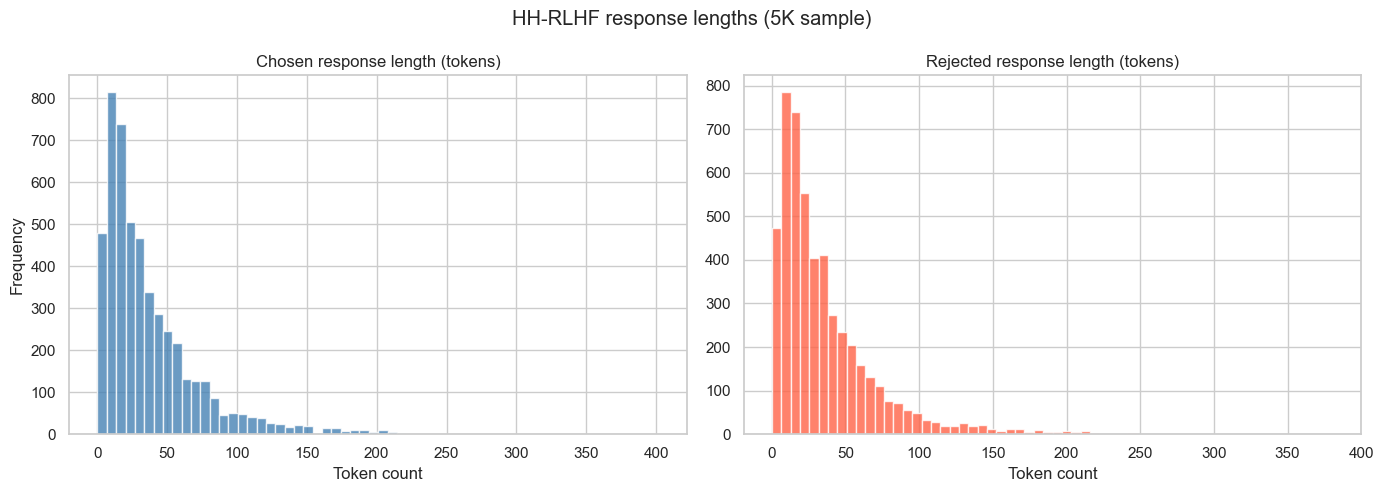

Chosen    mean: 37.8   median: 26.0   max: 402
Rejected  mean: 36.1   median: 25.0   max: 381


In [7]:
# 5000 rows is enough to see the shape without waiting around
sample_df = df.sample(5000, random_state=42).copy()
sample_df['chosen_len'] = sample_df['chosen_response'].str.split().str.len()
sample_df['rejected_len'] = sample_df['rejected_response'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sample_df['chosen_len'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Chosen response length (tokens)')
axes[0].set_xlabel('Token count')
axes[0].set_ylabel('Frequency')

axes[1].hist(sample_df['rejected_len'], bins=60, color='tomato', alpha=0.8, edgecolor='white')
axes[1].set_title('Rejected response length (tokens)')
axes[1].set_xlabel('Token count')

plt.suptitle('HH-RLHF response lengths (5K sample)')
plt.tight_layout()
plt.savefig('../../reports/figures/01_response_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

for label, col in [('Chosen  ', 'chosen_len'), ('Rejected', 'rejected_len')]:
    s = sample_df[col]
    print(f'{label}  mean: {s.mean():.1f}   median: {s.median():.1f}   max: {s.max()}')


## Train / val / test split

70/15/15 with a fixed seed. Every experiment in this project sees the exact same split.

In [8]:
splits = split_dataframe(df, train=0.70, val=0.15, test=0.15, seed=42)

for name, split in splits.items():
    print(f'{name:6s}: {len(split):>7,} rows  ({len(split)/len(df)*100:.1f}%)')

2026-05-15 18:57:33  INFO      inference_lens.data.loader  Split 'train': 63726 rows
2026-05-15 18:57:33  INFO      inference_lens.data.loader  Split 'val': 13655 rows
2026-05-15 18:57:33  INFO      inference_lens.data.loader  Split 'test': 13657 rows
train :  63,726 rows  (70.0%)
val   :  13,655 rows  (15.0%)
test  :  13,657 rows  (15.0%)


## Save to disk

Cache the flattened DataFrame so the next notebook skips straight to features without re-flattening 170K rows.

In [9]:
import os
os.makedirs('../../data/processed', exist_ok=True)

df.to_parquet('../../data/processed/hh_rlhf_flat.parquet', index=False)
print(f'Saved {len(df):,} rows to data/processed/hh_rlhf_flat.parquet')

Saved 91,038 rows to data/processed/hh_rlhf_flat.parquet
